[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

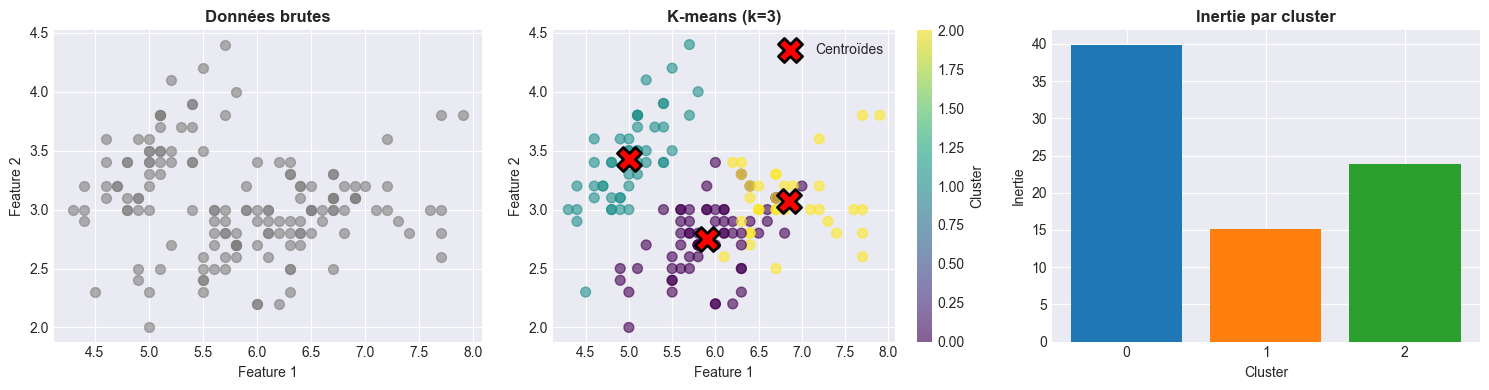

Inertie totale: 78.85
ARI : 0.730
NMI : 0.758


In [ ]:
# Metriques externes avec des vrais labels
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import numpy as np

warnings.filterwarnings("ignore")

# Configuration matplotlib
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
np.random.seed(42)

iris = load_iris()
y_true = iris.target
X = iris.data
print(iris.data)
# Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(iris.data)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Données brutes
axes[0].scatter(X[:, 0], X[:, 1], c="gray", alpha=0.6, s=50)
axes[0].set_title("Données brutes", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Clusters prédits
scatter = axes[1].scatter(X[:, 0], X[:, 1], c=y_pred, cmap="viridis", alpha=0.6, s=50)
axes[1].scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="red",
    marker="X",
    s=300,
    edgecolors="black",
    linewidths=2,
    label="Centroïdes",
)
axes[1].set_title("K-means (k=3)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()
plt.colorbar(scatter, ax=axes[1], label="Cluster")

# Inertie par cluster
inertia_by_cluster = []
for i in range(3):
    cluster_points = X[y_pred == i]
    center = kmeans.cluster_centers_[i]
    inertia = np.sum((cluster_points - center) ** 2)
    print(inertia)
    inertia_by_cluster.append(inertia)

axes[2].bar(
    range(3), inertia_by_cluster, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
)
axes[2].set_title("Inertie par cluster", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Inertie")
axes[2].set_xticks(range(3))

plt.tight_layout()
plt.show()

print(f"Inertie totale: {sum(inertia_by_cluster):.2f}")

# Evaluation externe
ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
print(f"ARI : {ari:.3f}")
print(f"NMI : {nmi:.3f}")